# MLP Regression: Sine Data Set 

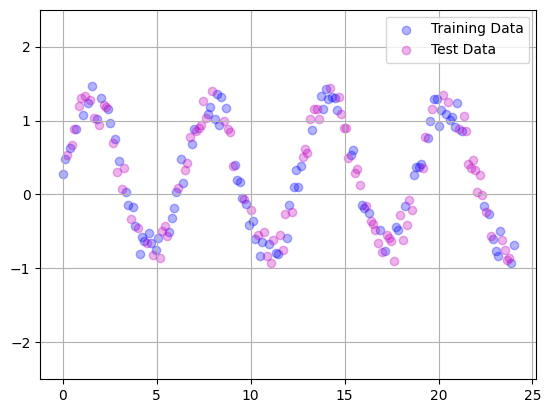

In [2]:
import numpy as np
from time import time
from scipy.stats import loguniform, randint
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Generate the Sine Data Set
np.random.seed(0)
x = np.linspace(0,24,200).reshape(-1,1)
y = np.sin(x) + 0.5*np.random.rand(x.size,1)

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.5, random_state=0)
y_train, y_test = np.ravel(y_train), np.ravel(y_test)

def plotData(X_train,X_test,y_train,y_test):
    plt.scatter(X_train,y_train,color='b',alpha=0.3,label='Training Data')
    plt.scatter(X_test,y_test,color='m',alpha=0.3,label='Test Data')
    plt.ylim([-2.5, 2.5])
    plt.grid()
    
plotData(X_train, X_test, y_train, y_test)
plt.legend()
plt.show()

In [3]:
pipeline = Pipeline(
    steps=[("preprocess", StandardScaler()),
           ("regress", MLPRegressor(max_iter=5000))]
)

model_params = {'regress__alpha': loguniform(1e-4, 10),
                'regress__solver': ['sgd','adam'],
                'regress__hidden_layer_sizes': 
                    [(i, j, k) for i in range(10, 51) for j in range(10, i+1) for k in range(10, j+1)],
                'regress__activation': ['identity','logistic','tanh','relu']}

n_iter = 30
random_search = RandomizedSearchCV(pipeline,
                                   param_distributions=model_params, 
                                   n_iter=n_iter, verbose=2)

start = time()
random_search.fit(X_train, y_train)
print("RandomizedSearchCV took %.2f seconds for %d candidates parameter settings."
        % ((time() - start), n_iter))

# Print best parameters after tuning
print(random_search.best_params_)
  
# Print how our model looks after hyper-parameter tuning
print(random_search.best_estimator_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END regress__activation=tanh, regress__alpha=2.5411061718361596, regress__hidden_layer_sizes=(46, 44, 31), regress__solver=adam; total time=   0.1s
[CV] END regress__activation=tanh, regress__alpha=2.5411061718361596, regress__hidden_layer_sizes=(46, 44, 31), regress__solver=adam; total time=   0.2s
[CV] END regress__activation=tanh, regress__alpha=2.5411061718361596, regress__hidden_layer_sizes=(46, 44, 31), regress__solver=adam; total time=   0.2s
[CV] END regress__activation=tanh, regress__alpha=2.5411061718361596, regress__hidden_layer_sizes=(46, 44, 31), regress__solver=adam; total time=   0.1s
[CV] END regress__activation=tanh, regress__alpha=2.5411061718361596, regress__hidden_layer_sizes=(46, 44, 31), regress__solver=adam; total time=   0.1s
[CV] END regress__activation=relu, regress__alpha=0.0007907121056225577, regress__hidden_layer_sizes=(42, 32, 10), regress__solver=sgd; total time=   0.0s
[CV] END regress__

(100, 1) (100, 1) (100,) (100,)


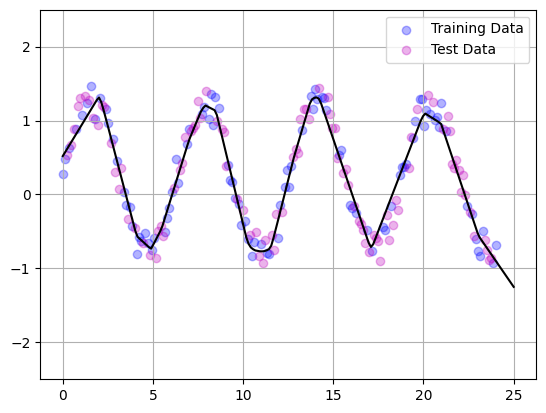

[[ 0.49508036  1.21438127]
 [-0.54799032  1.25714504]
 [-0.02811435  0.61787026]
 [ 0.51944764 -0.26517247]
 [-0.75211345  1.06477143]
 [ 0.87541806  0.3300023 ]
 [-0.73400186  0.89007541]
 [ 1.14569781 -0.89616177]
 [ 1.08848028  1.27639843]
 [-0.71381316 -0.4138081 ]
 [ 1.15242158  0.93411017]
 [-0.12320297  0.89442926]
 [-0.21829159  0.36120616]
 [-0.63568935 -0.21126459]
 [ 1.14977108 -0.06261649]
 [ 0.72434073  1.19334041]
 [ 0.67046571 -0.45929496]
 [-0.10793953  0.33857471]
 [-0.16837875 -0.66042627]
 [ 1.00773872  0.84919321]
 [ 1.24674392  0.03982601]
 [ 0.19623587 -0.62636144]
 [ 0.24191372 -0.41994035]
 [ 0.16206289  0.3551462 ]
 [-0.22752932  0.89463913]
 [ 0.44170683  1.08876398]
 [ 0.6649069   0.40829137]
 [ 1.31446441 -0.007972  ]
 [ 0.95360109  1.31647144]
 [-0.85350022 -0.49524481]
 [ 0.81036615  0.94640985]
 [ 1.1676032   0.42353427]
 [-0.54017699 -0.61354732]
 [ 1.0396252   1.15473486]
 [ 0.26582     0.69988817]
 [ 1.0141221  -0.56334634]
 [ 0.34224012  0.2946493 ]
 

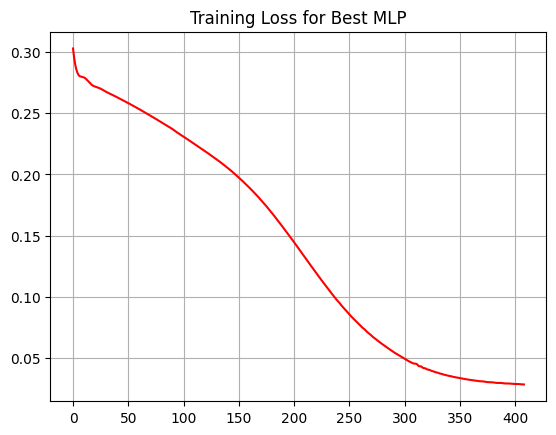

In [5]:
X_all = np.linspace(0,25,200).reshape(-1,1)
y_pred = random_search.predict(X_all)
plotData(X_train, X_test, y_train, y_test)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
plt.legend()
plt.plot(X_all,y_pred,'k')
plt.show()

loss_values = random_search.best_estimator_[1].loss_curve_
plt.plot(loss_values,'r')
plt.title('Training Loss for Best MLP')
plt.grid()
print(np.vstack((random_search.predict(X_train),y_test)).T)

In this example, three hidden layers were used in the MLP Regressor in order to fit the sine data set. In the hyper-parameter distributions, the number of hidden neurons were set to decrease at each succeeding layer. Try different number of layers and search ranges to see if Random Search can find a good architecture. 